In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from abc import ABC, abstractmethod
import numpy as np
from sklearn.metrics import classification_report, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif


In [30]:
df = pd.read_csv('Wholesale customers data.csv')

X = df.values

print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")

scaler = StandardScaler()
X = scaler.fit_transform(X)

Признаков: 8, Объектов: 440


In [31]:
clustering = DBSCAN(eps=2, min_samples=3).fit(X)
dbscan_labels = clustering.labels_

n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 15


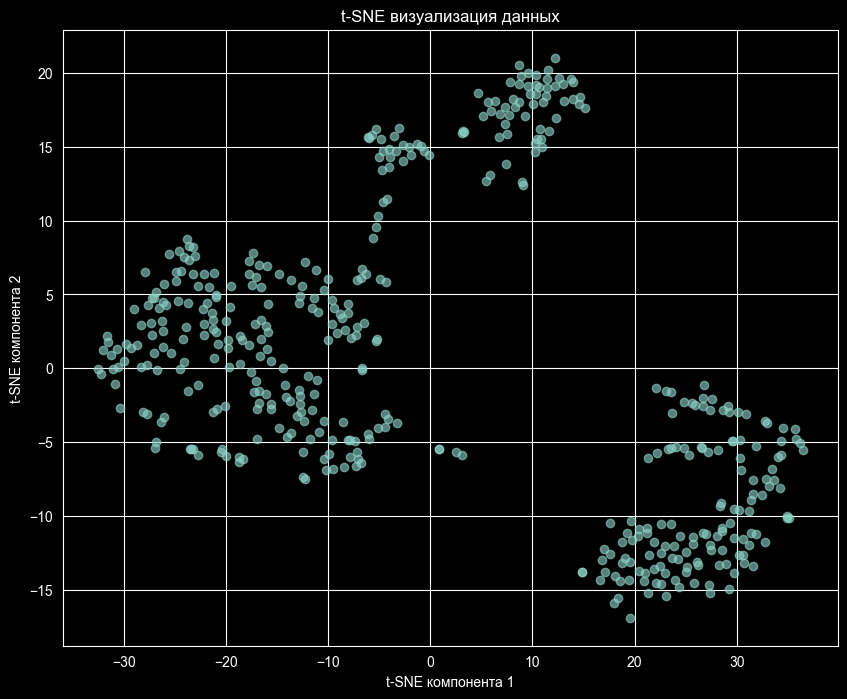

In [32]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6)
plt.title('t-SNE визуализация данных')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(True)
plt.show()

In [33]:
unique, counts = np.unique(dbscan_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")

Cluster -1: 15
Cluster 0: 133
Cluster 1: 292


C:\Users\User\AppData\Local\Temp\ipykernel_4464\635981010.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


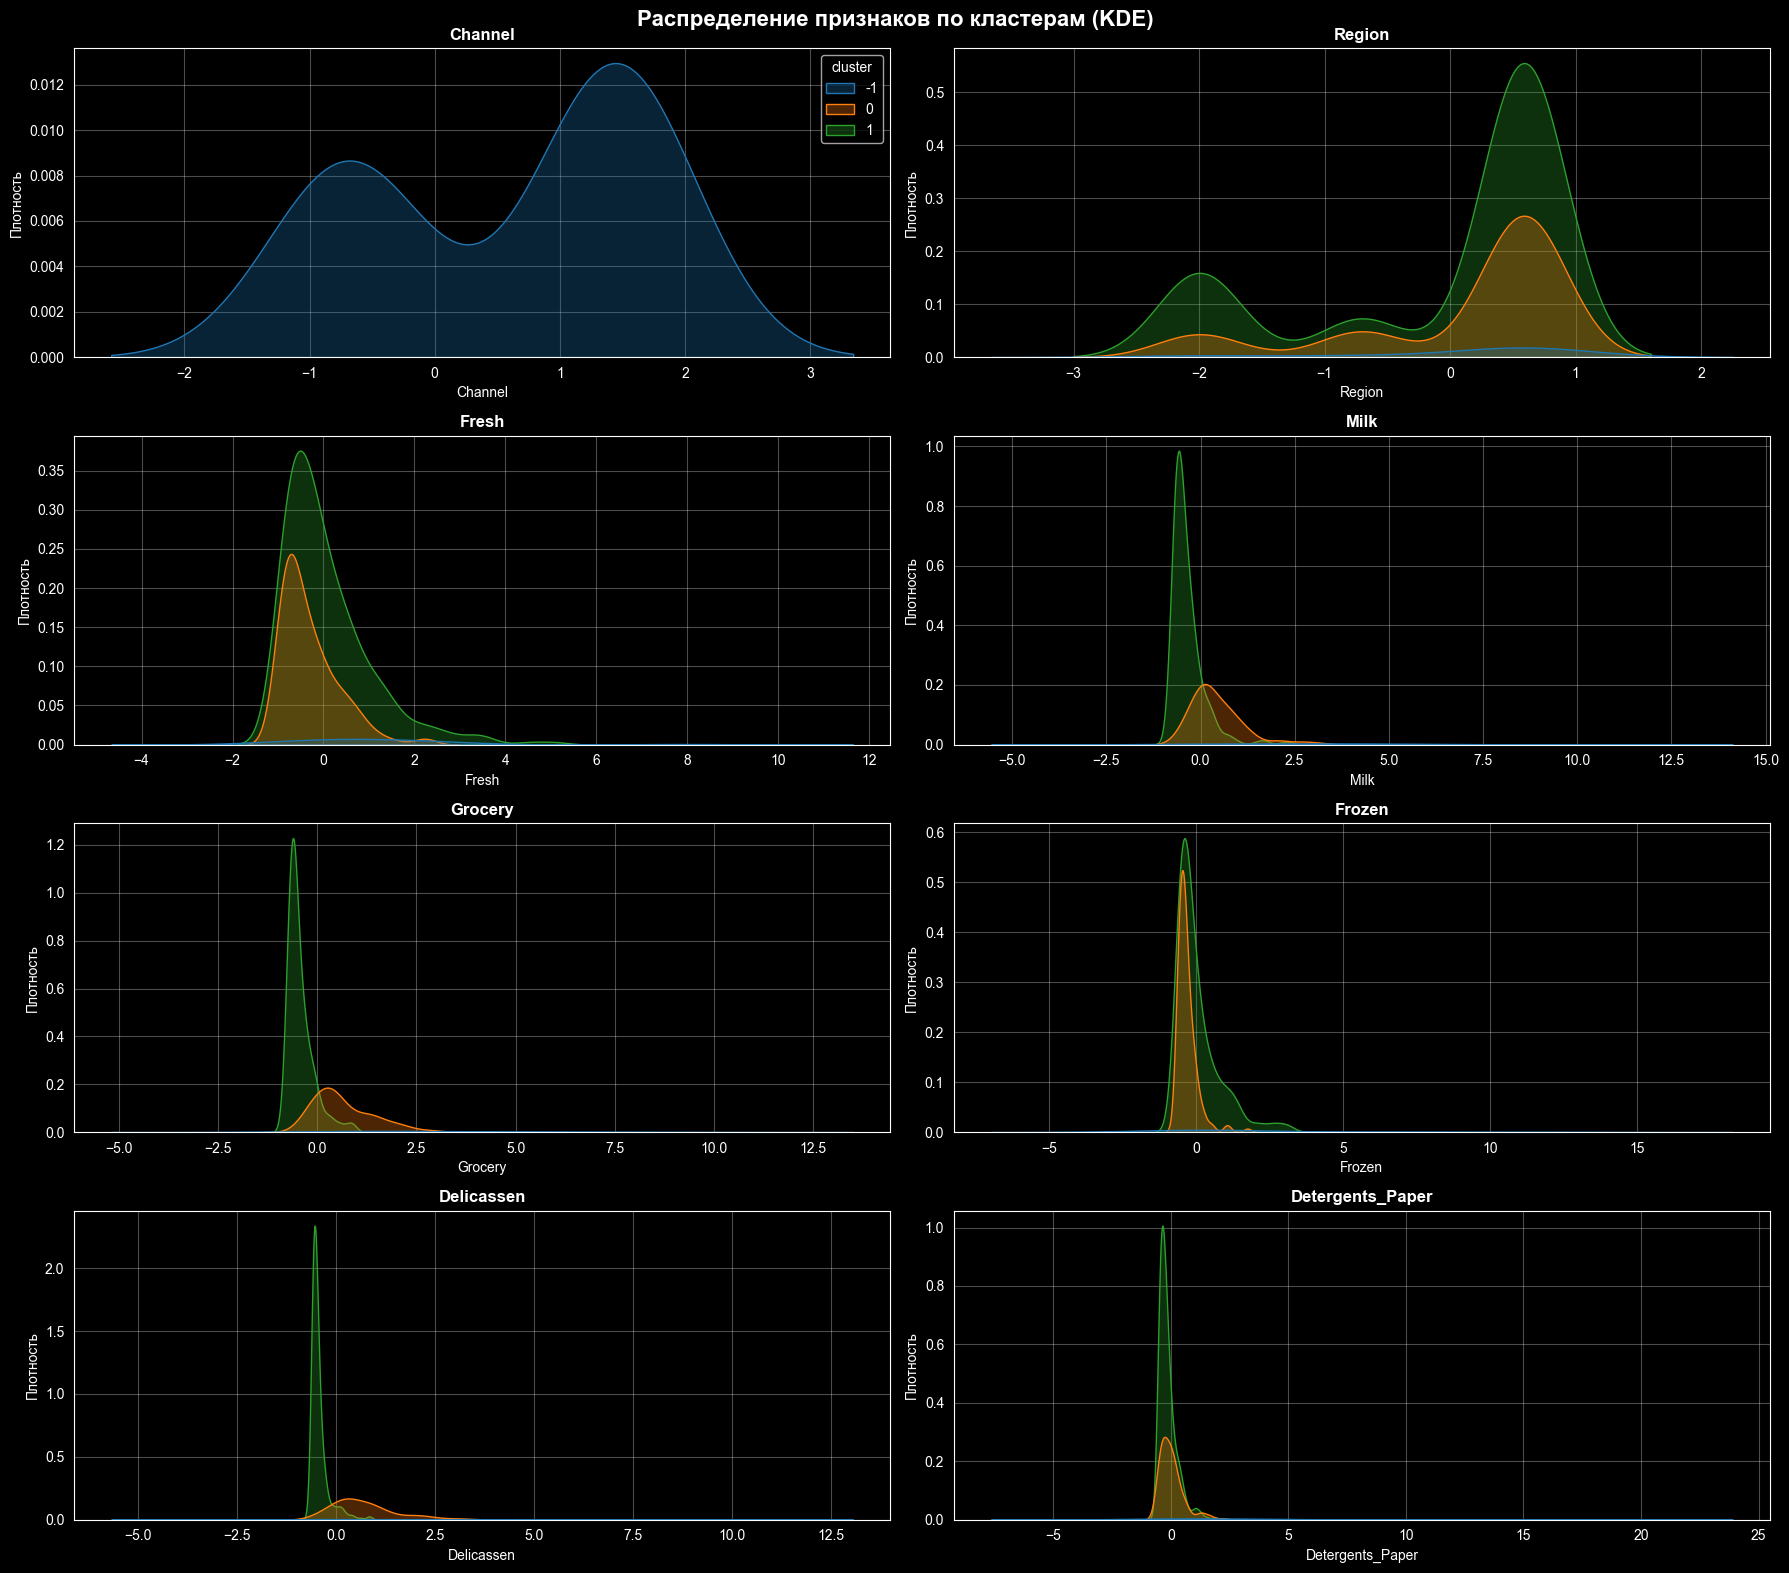

In [34]:
features = ['Channel', 'Region', 'Fresh', 'Milk',
            'Grocery', 'Frozen', 'Delicassen', 'Detergents_Paper']

X_df = pd.DataFrame(X, columns=features)
X_df['cluster'] = dbscan_labels

fig, axes = plt.subplots(4, 2, figsize=(18, 16))

for i, feature in enumerate(features):
    row = i // 2
    col = i % 2

    sns.kdeplot(
        data=X_df,
        x=feature,
        hue='cluster',
        fill=True,
        alpha=0.3,
        ax=axes[row, col],
        palette='tab10'
    )
    axes[row, col].set_title(feature, fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(feature, fontsize=10)
    axes[row, col].set_ylabel('Плотность', fontsize=10)
    axes[row, col].grid(True, alpha=0.3)

    if i != 0:
        axes[row, col].legend_.remove()

plt.suptitle('Распределение признаков по кластерам (KDE)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
df = pd.read_csv('Wholesale customers data.csv')
print(df.columns.tolist())

X = df.dropna(axis=1, how='all')
X.fillna(df.mean(numeric_only=True), inplace=True)

print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")

scaler = StandardScaler()
X = scaler.fit_transform(X)

['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Признаков: 8, Объектов: 440


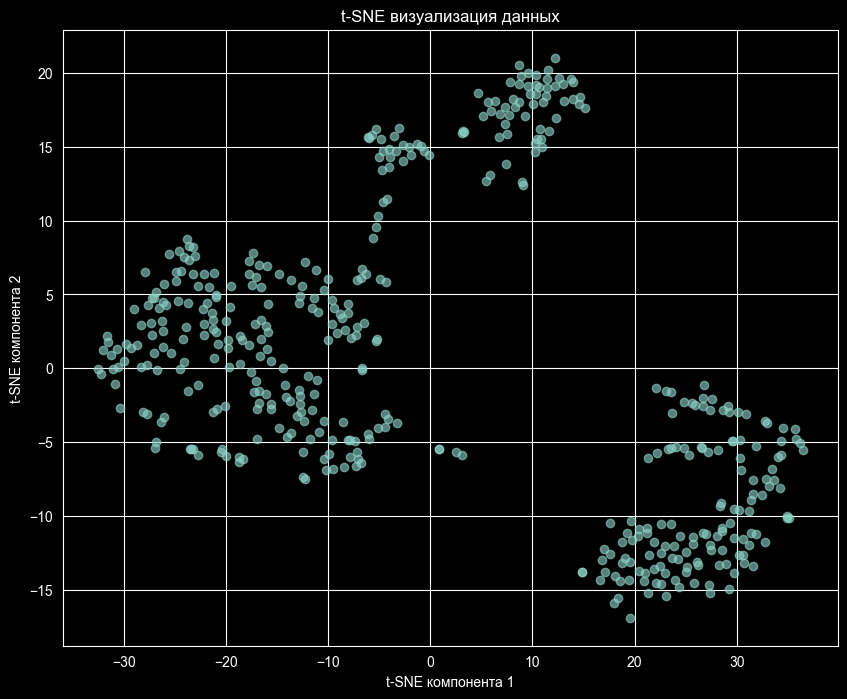

In [36]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6)
plt.title('t-SNE визуализация данных')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(True)
plt.show()

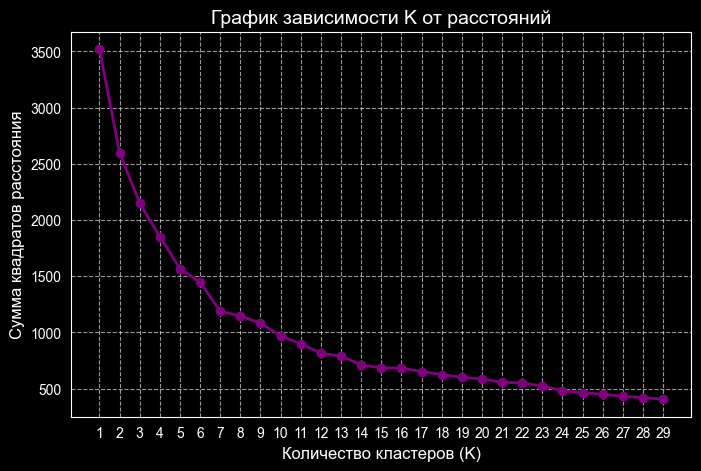

In [37]:
mean_distances = []
k_range = range(1, 30)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)
    mean_distances.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, mean_distances, marker='o', color='purple', linestyle='-', linewidth=2)
plt.xlabel('Количество кластеров (K)', fontsize=12)
plt.ylabel('Сумма квадратов расстояния', fontsize=12)
plt.title('График зависимости K от расстояний', fontsize=14)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [38]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X)

labels_kmeans = kmeans.labels_

score = kmeans.score(X)
print(f"Score: {score:.2f}")
for i in range(2):
    print(f"Кластер {i}: {np.sum(labels_kmeans==i)} объектов")


Score: -2600.38
Кластер 0: 140 объектов
Кластер 1: 300 объектов


In [39]:
def analyze_cluster_features(X, labels, feature_names=None, n_top=10):
    if feature_names is None:
        feature_names = [f'Feature_{i}' for i in range(X.shape[1])]

    df = pd.DataFrame(X, columns=feature_names)
    df['cluster'] = labels

    if -1 in labels:
        df = df[df['cluster'] != -1]
        print(f"Удалено шумовых точек: {np.sum(labels == -1)}")

    clusters = sorted(df['cluster'].unique())
    n_clusters = len(clusters)

    print(f"АНАЛИЗ ПРИЗНАКОВ ДЛЯ {n_clusters} КЛАСТЕРОВ")

    X_clean = df.drop('cluster', axis=1).values
    y_clean = df['cluster'].values

    f_scores, p_values = f_classif(X_clean, y_clean)

    feature_importance = pd.DataFrame({
        'Признак': feature_names,
        'F-статистика': f_scores,
        'p-значение': p_values
    }).sort_values('F-статистика', ascending=False)

    print("ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ (ANOVA F-тест):")
    print(feature_importance.head(n_top).to_string(index=False))

    plt.figure(figsize=(12, 6))
    top_features = feature_importance.head(n_top)
    plt.barh(top_features['Признак'], top_features['F-статистика'], color='skyblue')
    plt.xlabel('F-статистика')
    plt.title('Топ признаков, разделяющих кластеры')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    cluster_means = df.groupby('cluster').mean()

    cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

    plt.figure(figsize=(14, max(6, n_clusters * 0.6)))
    sns.heatmap(
        cluster_means_norm[feature_importance.head(n_top)['Признак'].tolist()],
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        cbar_kws={'label': 'Отклонение от среднего (в std)'}
    )
    plt.title('Средние значения топ-признаков по кластерам')
    plt.xlabel('Признаки')
    plt.ylabel('Кластер')
    plt.tight_layout()
    plt.show()

    global_mean = df.drop('cluster', axis=1).mean()

    print("ОПИСАНИЕ КАЖДОГО КЛАСТЕРА:")

    for cluster in clusters:
        size = np.sum(df['cluster'] == cluster)
        cluster_mean = cluster_means.loc[cluster]
        deviation = cluster_mean - global_mean

        top_high = deviation.nlargest(3)
        top_low = deviation.nsmallest(3)

        print(f"КЛАСТЕР {cluster} (n={size}, {size/len(df)*100:.1f}%)")

        if not top_high.empty:
            print("  ВЫШЕ СРЕДНЕГО:")
            for feat, val in top_high.items():
                print(f"    {feat}: +{val:.3f}")

        if not top_low.empty:
            print("  НИЖЕ СРЕДНЕГО:")
            for feat, val in top_low.items():
                print(f"    {feat}: {val:.3f}")

    return feature_importance, cluster_means

Всего признаков: 8
АНАЛИЗ ПРИЗНАКОВ ДЛЯ 2 КЛАСТЕРОВ
ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ (ANOVA F-тест):
         Признак  F-статистика    p-значение
         Channel   4926.443575 2.071514e-240
Detergents_Paper    314.860180  1.783543e-53
         Grocery    295.931402  4.797564e-51
            Milk    165.511163  2.355363e-32
          Frozen     12.690797  4.077852e-04
      Delicassen     10.275840  1.446471e-03
           Fresh      7.661523  5.880266e-03
          Region      3.421655  6.501986e-02


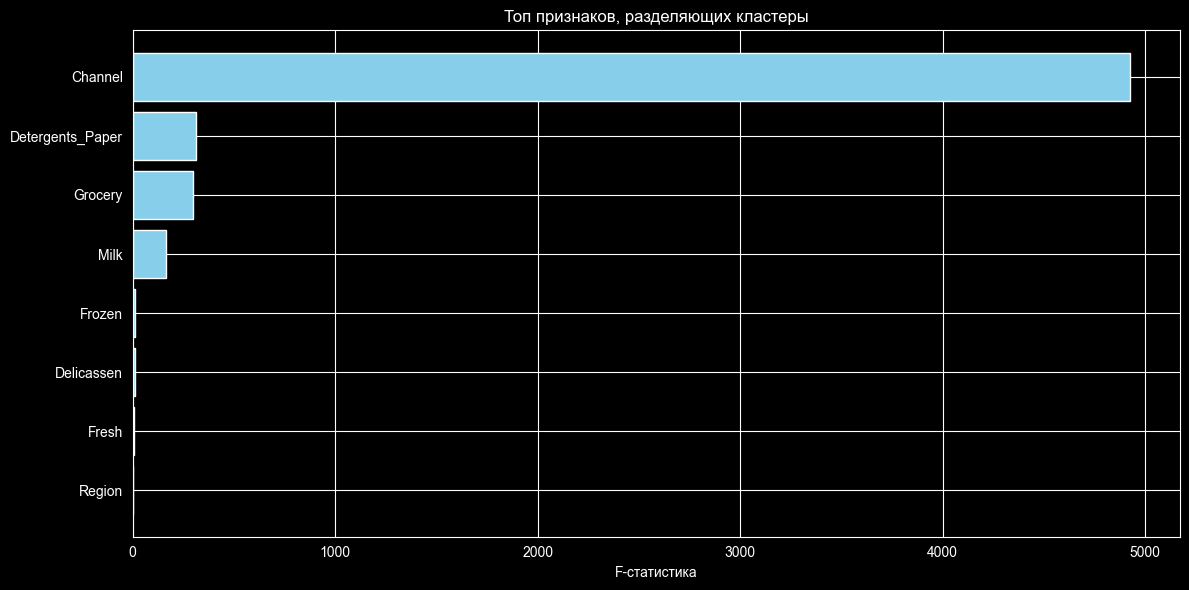

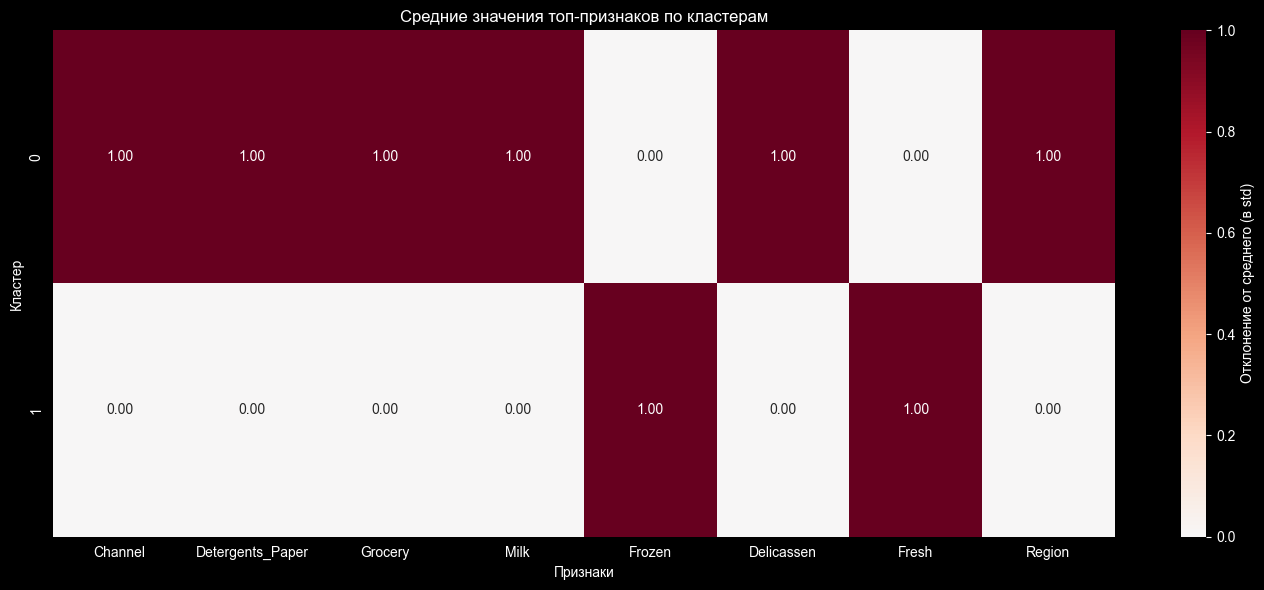

ОПИСАНИЕ КАЖДОГО КЛАСТЕРА:
КЛАСТЕР 0 (n=140, 31.8%)
  ВЫШЕ СРЕДНЕГО:
    Channel: +1.403
    Detergents_Paper: +0.947
    Grocery: +0.930
  НИЖЕ СРЕДНЕГО:
    Frozen: -0.246
    Fresh: -0.192
    Region: 0.129
КЛАСТЕР 1 (n=300, 68.2%)
  ВЫШЕ СРЕДНЕГО:
    Frozen: +0.115
    Fresh: +0.090
    Region: +-0.060
  НИЖЕ СРЕДНЕГО:
    Channel: -0.655
    Detergents_Paper: -0.442
    Grocery: -0.434


In [40]:
feature_names = df.columns.tolist()

print(f"Всего признаков: {len(feature_names)}")

importance_kmeans, means_kmeans = analyze_cluster_features(
    X,
    labels_kmeans,
    feature_names,
    n_top=10
)

In [41]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X , clusters)
print(score)

0.37415730136485814


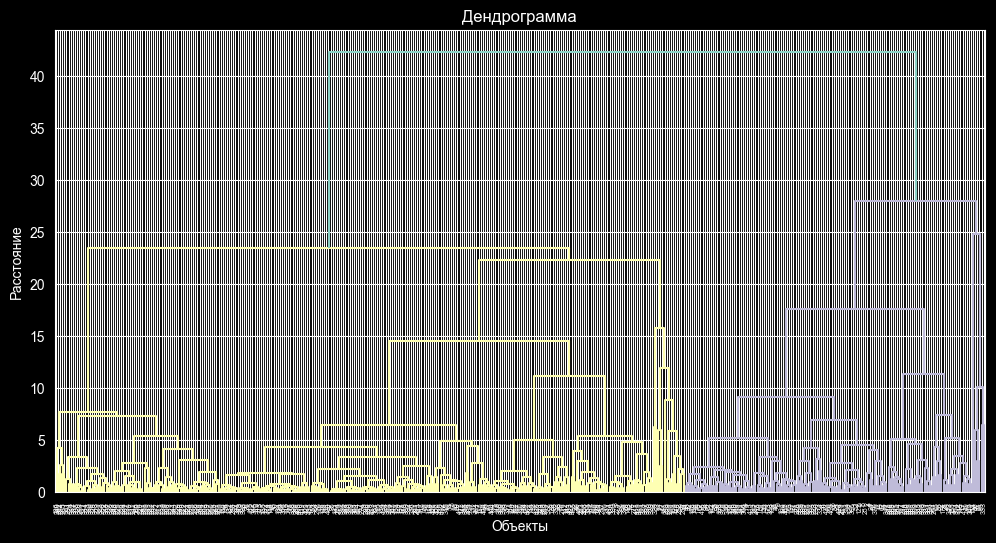

Кластер 0: 142 объектов
Кластер 1: 298 объектов


In [42]:
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Дендрограмма')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.show()

model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = model.fit_predict(X)

for i in range(2):
    print(f"Кластер {i}: {np.sum(labels==i)} объектов")

АНАЛИЗ ПРИЗНАКОВ ДЛЯ 2 КЛАСТЕРОВ
ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ (ANOVA F-тест):
         Признак  F-статистика   p-значение
         Channel  20733.899536 0.000000e+00
Detergents_Paper    291.059520 2.073047e-50
         Grocery    256.660256 8.514455e-46
            Milk    121.287937 4.571258e-25
          Frozen     13.127895 3.250409e-04
           Fresh     12.279916 5.049923e-04
      Delicassen      5.387873 2.073535e-02
          Region      1.691681 1.940634e-01


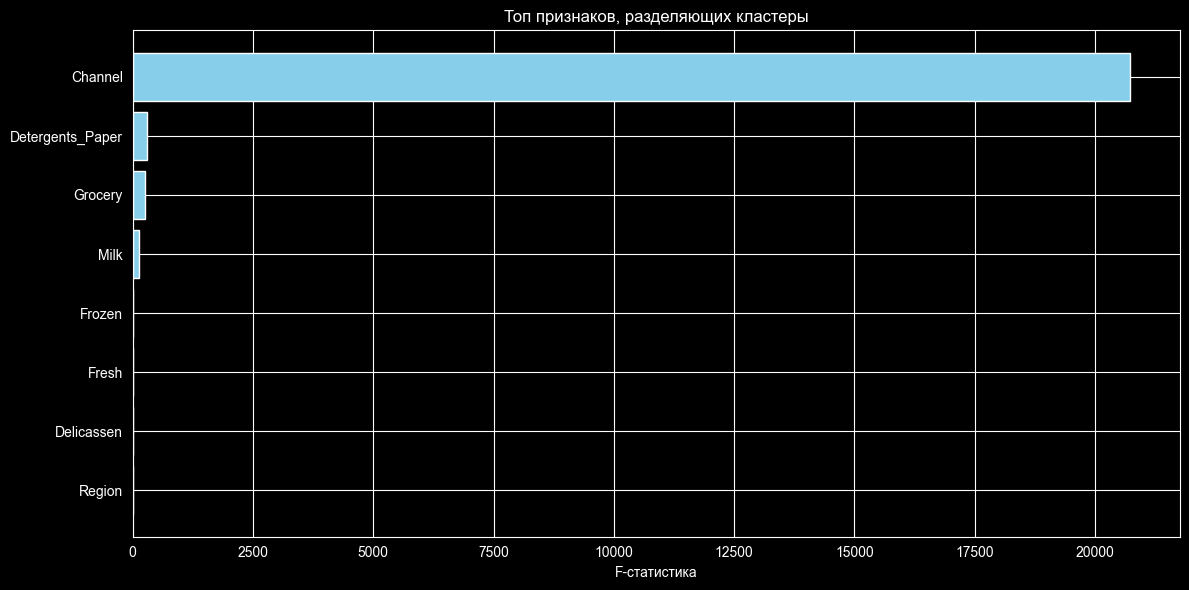

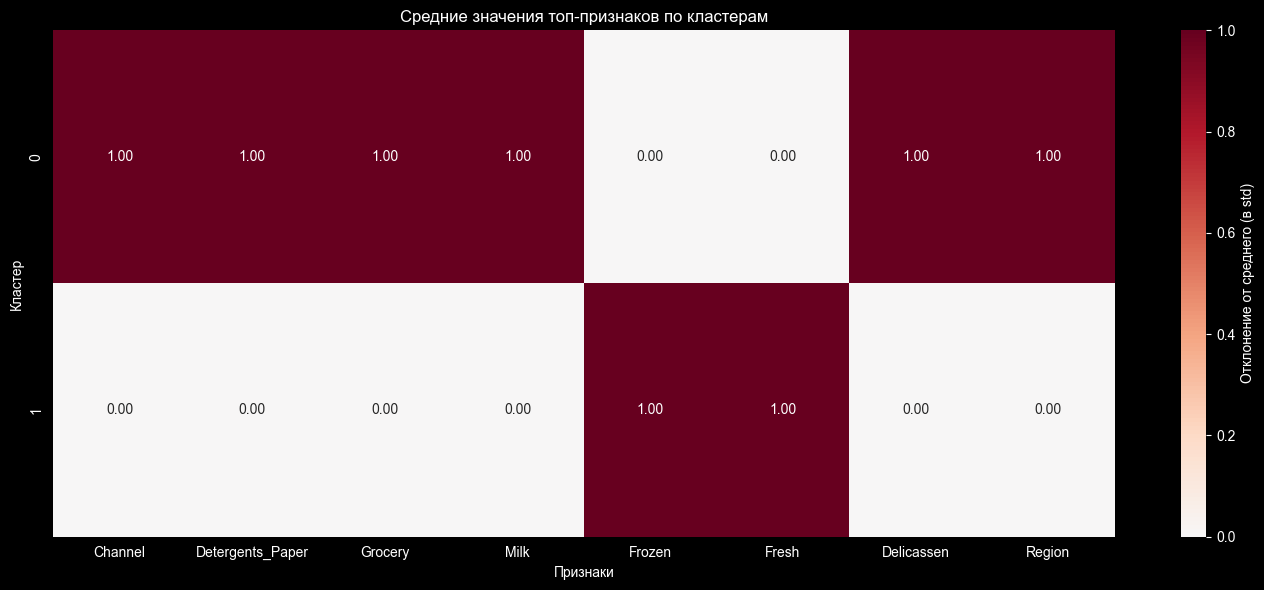

ОПИСАНИЕ КАЖДОГО КЛАСТЕРА:
КЛАСТЕР 0 (n=142, 32.3%)
  ВЫШЕ СРЕДНЕГО:
    Channel: +1.434
    Detergents_Paper: +0.915
    Grocery: +0.881
  НИЖЕ СРЕДНЕГО:
    Frozen: -0.247
    Fresh: -0.239
    Region: 0.090
КЛАСТЕР 1 (n=298, 67.7%)
  ВЫШЕ СРЕДНЕГО:
    Frozen: +0.118
    Fresh: +0.114
    Region: +-0.043
  НИЖЕ СРЕДНЕГО:
    Channel: -0.683
    Detergents_Paper: -0.436
    Grocery: -0.420


In [43]:
importance_kmeans, means_kmeans = analyze_cluster_features(
    X,
    labels,
    feature_names,
    n_top=10
)

In [44]:
score = silhouette_score(X , labels)
print(score)

0.3680209405194812
